# OpenMM Ubiquitin MD Simulation Tutorial

Complete workflow for 1 ns molecular dynamics simulation

**Expected Timeline:** ~1-1.5 hours (GPU-accelerated)
**Expected Results:** RMSD 0.10–0.15 nm, Rg ~1.18 nm

## Setup and Imports

In [1]:
import os
import sys
import time
import urllib.request
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
import mdtraj as md
import openmm as mm
from openmm import LangevinIntegrator, MonteCarloBarostat, Platform
from openmm.app import (
    PME,
    CheckpointReporter,
    DCDReporter,
    ForceField,
    HBonds,
    Modeller,
    PDBFile,
    Simulation,
    StateDataReporter,
)
from openmm.unit import (
    bar,
    femtoseconds,
    kelvin,
    kilocalories_per_mole,
    molar,
    nanometer,
    picosecond,
)

In [4]:
print("=" * 70)
print("OpenMM Ubiquitin MD Simulation")
print("=" * 70)
print(f"OpenMM version: {mm.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

os.makedirs("output", exist_ok=True)
os.makedirs("input", exist_ok=True)
print("✓ Directories created")
print("=" * 70)

OpenMM Ubiquitin MD Simulation
OpenMM version: 8.5.1
Numpy version: 2.4.4
Start time: 2026-05-27 08:49:38
✓ Directories created


## Prepare platform

In [5]:
preferred = ["CUDA", "Metal", "OpenCL", "CPU"]
platform = None
properties = {}

for name in preferred:
    try:
        candidate = Platform.getPlatformByName(name)
        props = {"Precision": "mixed"} if name == "CUDA" else {}
        dummy_sys = mm.System()
        dummy_sys.addParticle(1.0)
        dummy_int = mm.VerletIntegrator(1.0 * femtoseconds)
        mm.Context(dummy_sys, dummy_int, candidate, props)
        platform, properties = candidate, props
        print(f"Platform: {name}")
        break
    except mm.OpenMMException as e:
        print(f"  {name} unavailable: {e}")

  CUDA unavailable: There is no registered Platform called "CUDA"
  Metal unavailable: There is no registered Platform called "Metal"
Platform: OpenCL


## Download Ubiquitin PDB

In [6]:
pdb_file = "input/1UBQ.pdb"

if not os.path.exists(pdb_file):
    print("Downloading ubiquitin (PDB: 1UBQ)...")
    url = "https://files.rcsb.org/download/1UBQ.pdb"
    urllib.request.urlretrieve(url, pdb_file)
    print(f"✓ Downloaded to {pdb_file}")
else:
    print(f"✓ {pdb_file} already exists")

file_size = os.path.getsize(pdb_file) / 1024
print(f"✓ File size: {file_size:.1f} KB")

✓ input/1UBQ.pdb already exists
✓ File size: 76.7 KB


## Step 1: Load Structure

In [7]:
print("\n" + "=" * 70)
print("STEP 1: Load Structure")
print("=" * 70)

pdb = PDBFile("input/1UBQ.pdb")
topology = pdb.topology
positions = pdb.positions

n_atoms = topology.getNumAtoms()
n_residues = topology.getNumResidues()

print("✓ Loaded ubiquitin")
print(f"  - Atoms: {n_atoms}")
print(f"  - Residues: {n_residues}")
print("✓ Ready for system setup")


STEP 1: Load Structure
✓ Loaded ubiquitin
  - Atoms: 660
  - Residues: 134
✓ Ready for system setup


## Step 2: System Setup (Water + Ions)

In [8]:
print("\n" + "=" * 70)
print("STEP 2: System Setup")
print("=" * 70)

print("Loading force field (AMBER99SB-ILDN + TIP3P)...")
forcefield = ForceField("amber99sbildn.xml", "tip3p.xml")

print("Adding water and ions...")
modeller = Modeller(topology, positions)
modeller.addHydrogens(forcefield)
modeller.addSolvent(forcefield, model="tip3p", padding=1.0 * nanometer, ionicStrength=0.15 * molar)

print("Creating system...")
system = forcefield.createSystem(
    modeller.topology,
    constraints=HBonds,
    rigidWater=True,
    nonbondedMethod=PME,
    nonbondedCutoff=1.0 * nanometer,
)

topology = modeller.topology
positions = modeller.positions

print("✓ System created")
print(f"  - Total atoms: {topology.getNumAtoms()}")
print(f"  - Forces: {system.getNumForces()}")


STEP 2: System Setup
Loading force field (AMBER99SB-ILDN + TIP3P)...
Adding water and ions...
Creating system...
✓ System created
  - Total atoms: 17300
  - Forces: 5


## Step 3: Energy Minimisation

In [9]:
print("\n" + "=" * 70)
print("STEP 3: Energy Minimisation")
print("=" * 70)

integrator = LangevinIntegrator(300 * kelvin, 1.0 / picosecond, 2.0 * femtoseconds)

simulation = Simulation(topology, system, integrator, platform, properties)
simulation.context.setPositions(positions)

print("Running minimisation...")
start = time.time()
simulation.minimizeEnergy(maxIterations=5000)
simulation.saveCheckpoint("output/step3_min.chk")
elapsed = time.time() - start

state = simulation.context.getState(getEnergy=True, getPositions=True, enforcePeriodicBox=True)

# Get box vectors from the state and set them on topology
box_vectors = state.getPeriodicBoxVectors()
energy = state.getPotentialEnergy().in_units_of(kilocalories_per_mole)
topology.setPeriodicBoxVectors(box_vectors)

print("✓ Minimization complete")
print(f"  - Final energy: {energy._value:.1f} kcal/mol")
print(f"  - Time: {elapsed:.1f}s")

with open("output/step3_minimised.pdb", "w") as f:
    PDBFile.writeFile(topology, state.getPositions(), f)
positions = state.getPositions()


STEP 3: Energy Minimisation
Running minimisation...
✓ Minimization complete
  - Final energy: -69046.7 kcal/mol
  - Time: 16.0s


## Step 4: NVT Equilibration (100 ps)

In [10]:
print("\n" + "=" * 70)
print("STEP 4: NVT Equilibration (100 ps)")
print("=" * 70)

simulation.reporters.clear()
simulation.context.setVelocitiesToTemperature(300 * kelvin)
simulation.reporters.append(
    StateDataReporter(
        sys.stdout, 5000, step=True, time=True, temperature=True, potentialEnergy=True
    )
)

print("Heating to 300K...")
start = time.time()
simulation.reporters.append(DCDReporter("output/step4_nvt.dcd", 5000))
simulation.step(50000)
simulation.saveState("output/step4_nvt.xml")  # Save full state (positions + velocities + box)
elapsed = time.time() - start

state = simulation.context.getState(getPositions=True, getVelocities=True, enforcePeriodicBox=True)
topology.setPeriodicBoxVectors(state.getPeriodicBoxVectors())

print(f"\n✓ NVT complete ({elapsed:.1f}s)")


STEP 4: NVT Equilibration (100 ps)
Heating to 300K...
#"Step","Time (ps)","Potential Energy (kJ/mole)","Temperature (K)"
5000,10.000000000000009,-232167.88860161533,299.94667254164267
10000,19.999999999999794,-232916.77532036533,299.1251817483134
15000,29.99999999999425,-232930.76360161533,300.3319447352541
20000,40.00000000000292,-233344.67375786533,302.2507037526624
25000,50.00000000001514,-232672.34953911533,303.6109194486759
30000,60.00000000002736,-233046.12297661533,299.22013944765274
35000,70.00000000001826,-232661.27141411533,301.1407389373234
40000,79.99999999999496,-232621.72453911533,299.5404616418566
45000,89.99999999997165,-232628.78313286533,302.916181179858
50000,99.99999999994834,-233385.19719536533,299.3415039229319

✓ NVT complete (71.3s)


## Step 5: NPT Equilibration (100 ps)

In [11]:
print("\n" + "=" * 70)
print("STEP 5: NPT Equilibration (100 ps)")
print("=" * 70)

simulation.reporters.clear()
system.addForce(MonteCarloBarostat(1 * bar, 300 * kelvin))
simulation.context.reinitialize(preserveState=True)

simulation.reporters.append(StateDataReporter(sys.stdout, 5000, step=True, time=True, density=True))

print("Equilibrating pressure...")
start = time.time()
simulation.reporters.append(DCDReporter("output/step5_npt.dcd", 5000))
simulation.step(50000)
simulation.saveState("output/step5_npt.xml")  # Save full state (positions + velocities + box)
elapsed = time.time() - start

state = simulation.context.getState(getPositions=True, getVelocities=True, enforcePeriodicBox=True)
topology.setPeriodicBoxVectors(state.getPeriodicBoxVectors())

print(f"\n✓ NPT complete ({elapsed:.1f}s)")


STEP 5: NPT Equilibration (100 ps)
Equilibrating pressure...
#"Step","Time (ps)","Density (g/mL)"
55000,109.99999999992504,1.0188988958520684
60000,119.99999999990173,1.0072595587827091
65000,129.99999999989262,1.0142029153850554
70000,139.99999999994037,1.0063302998164059
75000,149.99999999998812,1.0123076743392136
80000,160.00000000003587,1.0108792159224025
85000,170.00000000008362,1.0081814465231096
90000,180.00000000013137,1.0068993657238614
95000,190.0000000001791,1.011811267843215
100000,200.00000000022686,1.011494301637749

✓ NPT complete (80.9s)


## Step 6: Production MD (5 ns) - ⏱️ WARNING: 60 MIN ON GPU

In [12]:
sim_ns = 5  # 5 nanoseconds

print("\n" + "=" * 70)
print(f"STEP 6: Production MD ({sim_ns} ns)")
print("=" * 70)
print(f"⏱️  WARNING: ~{sim_ns * 12} min on OpenCL/CUDA, much longer on CPU")

simulation.reporters.clear()
simulation.reporters.append(DCDReporter("output/step6_trajectory.dcd", 5000))
simulation.reporters.append(
    StateDataReporter(
        "output/step6_energy.txt",
        5000,
        step=True,
        time=True,
        potentialEnergy=True,
        kineticEnergy=True,
        density=True,
    )
)
simulation.reporters.append(
    StateDataReporter(sys.stdout, 50000, step=True, time=True, potentialEnergy=True)
)
simulation.reporters.append(CheckpointReporter("output/step6_prod.chk", 50000))  # every 100 ps

print(f"Running {sim_ns} ns production MD...")
start = time.time()
simulation.step(sim_ns * 500000)
total_time = time.time() - start
hours = total_time / 3600
ns_per_day = sim_ns * 24 / hours
print("\n✓ Production complete!")
print(f"  - Runtime: {hours:.1f}h ({1 / hours:.1f} ns/day)")

state = simulation.context.getState(getPositions=True, getVelocities=True, enforcePeriodicBox=True)
topology.setPeriodicBoxVectors(state.getPeriodicBoxVectors())

with open("output/step6_final.pdb", "w") as f:
    PDBFile.writeFile(topology, state.getPositions(), f)


STEP 6: Production MD (5 ns)
⏱️  WARNING: ~60 min on OpenCL/CUDA, much longer on CPU
Running 5 ns production MD...
#"Step","Time (ps)","Potential Energy (kJ/mole)"
150000,300.00000000070435,-235818.12540820753
200000,400.00000000118183,-236571.77288913564
250000,500.0000000016593,-236075.69155106647
300000,599.9999999996356,-236610.11901191785
350000,699.999999997271,-236655.4849538235
400000,799.9999999949063,-236265.30149197765
450000,899.9999999925416,-236013.2114620828
500000,999.9999999901769,-236391.21628258703
550000,1099.9999999878123,-236751.59366324497
600000,1199.9999999854476,-236284.53340750956
650000,1299.999999983083,-236299.8423315829
700000,1399.9999999807183,-236069.68999798736
750000,1499.9999999783536,-236258.45404751878
800000,1599.9999999759889,-236556.44369072
850000,1699.9999999736242,-235962.96315148706
900000,1799.9999999712595,-236020.89389339066
950000,1899.9999999688948,-235908.20714891306
1000000,1999.9999999665301,-236751.1674979839
1050000,2099.99999996

## Step 7: Trajectory Analysis

In [13]:
print("\n" + "=" * 70)
print("STEP 7: Trajectory Analysis")
print("=" * 70)

print("Loading trajectories...")
top = "output/step3_minimised.pdb"
traj_nvt = md.load("output/step4_nvt.dcd", top=top)
traj_npt = md.load("output/step5_npt.dcd", top=top)
traj_prod = md.load("output/step6_trajectory.dcd", top=top)
traj = md.join([traj_nvt, traj_npt, traj_prod])
traj.image_molecules(inplace=True)  # unwrap PBC

n_nvt, n_npt, n_prod = traj_nvt.n_frames, traj_npt.n_frames, traj_prod.n_frames


prot = traj.atom_slice(traj.topology.select("protein"))
backbone = prot.topology.select("backbone")
ca = prot.atom_slice(prot.topology.select("name CA"))
prot.superpose(prot, frame=0, atom_indices=backbone)

print("Calculating RMSD...")
rmsd = md.rmsd(prot, prot[0], atom_indices=backbone)

print("Calculating RMSF...")
rmsf = md.rmsf(ca, ca[0])

print("Calculating Rg...")
rg = md.compute_rg(prot)

# Smart equilibration slicing
n_frames = len(rmsd)
eq_start = n_frames // 2  # Use second half

print("\n✓ Analysis complete")
print(f"  - Frames: {traj.n_frames}")
print(f"  - Duration: {traj.n_frames * 10 / 1000:.2f} ns")  # 10 ps per frame
print(f"  - Final RMSD: {rmsd[-1]:.3f} nm")

if n_frames > 1:
    print(f"  - Mean RMSD (last {n_frames - eq_start} frames): {rmsd[eq_start:].mean():.3f} nm")
    print(f"  - Std dev: {rmsd[eq_start:].std():.3f} nm")

print(f"  - Rg: {rg.mean():.3f} ± {rg.std():.3f} nm")
print(f"  - RMSF: mean {rmsf.mean():.3f} nm, max {rmsf.max():.3f} nm")

np.savetxt("output/step7_rmsd.txt", rmsd)
np.savetxt("output/step7_rmsf.txt", rmsf)
np.savetxt("output/step7_rg.txt", rg)


STEP 7: Trajectory Analysis
Loading trajectories...
Calculating RMSD...
Calculating RMSF...
Calculating Rg...

✓ Analysis complete
  - Frames: 520
  - Duration: 5.20 ns
  - Final RMSD: 0.111 nm
  - Mean RMSD (last 260 frames): 0.164 nm
  - Std dev: 0.031 nm
  - Rg: 1.176 ± 0.008 nm
  - RMSF: mean 0.065 nm, max 0.446 nm


## Step 8: Visualisation

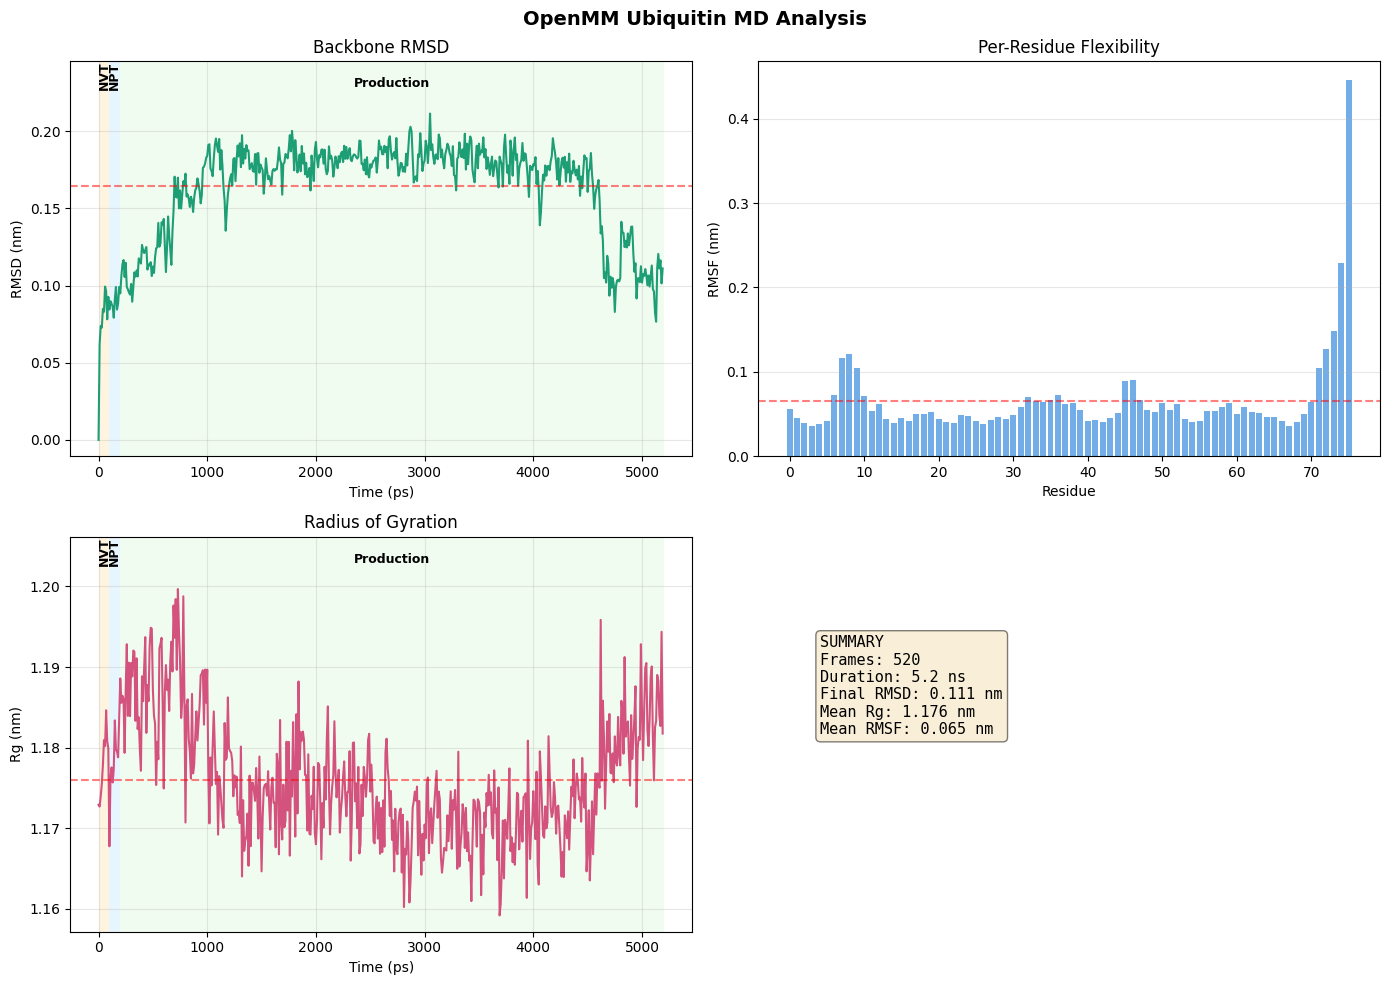

✓ Plot saved


In [17]:
dt_ps_per_frame = 5000 * 2e-3  # 10 ps
time_ps = np.arange(len(rmsd)) * dt_ps_per_frame
eq_start = len(rmsd) // 2

t_nvt_end = n_nvt * dt_ps_per_frame  # 100
t_npt_end = (n_nvt + n_npt) * dt_ps_per_frame  # 200
t_prod_end = (n_nvt + n_npt + n_prod) * dt_ps_per_frame

stages = [
    ("NVT", 0, t_nvt_end, "#FFD580"),
    ("NPT", t_nvt_end, t_npt_end, "#A0D8FF"),
    ("Production", t_npt_end, t_prod_end, "#C8F5C8"),
]


def shade_stages(ax, stages):
    if not stages:
        return
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + 0.10 * (ymax - ymin))
    ytext = ymax + 0.02 * (ymax - ymin)
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    for label, t0, t1, color in stages:
        ax.axvspan(t0, t1, facecolor=color, alpha=0.25, zorder=0)
        narrow = (t1 - t0) / x_range < 0.05
        ax.text(
            (t0 + t1) / 2,
            ytext,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            rotation=90 if narrow else 0,
        )


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("OpenMM Ubiquitin MD Analysis", fontsize=14, fontweight="bold")

axes[0, 0].plot(time_ps, rmsd, color="#1D9E75", lw=1.5)
axes[0, 0].axhline(rmsd[eq_start:].mean(), color="red", ls="--", alpha=0.5)
axes[0, 0].set_xlabel("Time (ps)")
axes[0, 0].set_ylabel("RMSD (nm)")
axes[0, 0].set_title("Backbone RMSD")
axes[0, 0].grid(alpha=0.3)
shade_stages(axes[0, 0], stages)

axes[0, 1].bar(range(len(rmsf)), rmsf, color="#378ADD", alpha=0.7)
axes[0, 1].axhline(rmsf.mean(), color="red", ls="--", alpha=0.5)
axes[0, 1].set_xlabel("Residue")
axes[0, 1].set_ylabel("RMSF (nm)")
axes[0, 1].set_title("Per-Residue Flexibility")
axes[0, 1].grid(alpha=0.3, axis="y")

axes[1, 0].plot(time_ps, rg, color="#D4537E", lw=1.5)
axes[1, 0].axhline(rg.mean(), color="red", ls="--", alpha=0.5)
axes[1, 0].set_xlabel("Time (ps)")
axes[1, 0].set_ylabel("Rg (nm)")
axes[1, 0].set_title("Radius of Gyration")
axes[1, 0].grid(alpha=0.3)
shade_stages(axes[1, 0], stages)

summary = (
    f"SUMMARY\nFrames: {traj.n_frames}\n"
    f"Duration: {traj.n_frames * dt_ps_per_frame / 1000:.1f} ns\n"
    f"Final RMSD: {rmsd[-1]:.3f} nm\n"
    f"Mean Rg: {rg.mean():.3f} nm\n"
    f"Mean RMSF: {rmsf.mean():.3f} nm"
)
axes[1, 1].text(
    0.1,
    0.5,
    summary,
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig("output/step8_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Plot saved")

In [15]:
# PyMOL

## Summary & Results

In [16]:
print("\n" + "=" * 70)
print("SIMULATION COMPLETE!")
print("=" * 70)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\n✓ Output files:")
print("  - output/step3_minimised.pdb")
print("  - output/step6_final.pdb")
print("  - output/step6_trajectory.dcd")
print("  - output/step6_energy.txt")
print("  - output/step7_rmsd.txt, step7_rmsf.txt, step7_rg.txt")
print("  - output/step8_analysis.png")

print("\n📊 Results:")
print(f"  - Final RMSD: {rmsd[-1]:.3f} nm")
print(f"  - Mean Rg: {rg.mean():.3f} ± {rg.std():.3f} nm")
ca_top = prot.atom_slice(prot.topology.select("name CA")).topology
ca_resids = [r.resSeq for r in ca_top.residues]
print(ca_resids)
print(f"  - Max RMSF: {rmsf.max():.3f} nm (residue {ca_resids[rmsf.argmax()]})")

print("\n🔬 Next steps:")
print("  - vmd output/step6_final.pdb output/step6_trajectory.dcd")
print("  - Run 3-5 independent simulations")
print("  - Compare with experimental data (NMR, SAXS)")
print("  - Secondary structure analysis")
print("  - Hydrogen bond networks")
print("=" * 70)


SIMULATION COMPLETE!
End time: 2026-05-27 10:36:25

✓ Output files:
  - output/step3_minimised.pdb
  - output/step6_final.pdb
  - output/step6_trajectory.dcd
  - output/step6_energy.txt
  - output/step7_rmsd.txt, step7_rmsf.txt, step7_rg.txt
  - output/step8_analysis.png

📊 Results:
  - Final RMSD: 0.111 nm
  - Mean Rg: 1.176 ± 0.008 nm
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76]
  - Max RMSF: 0.446 nm (residue 76)

🔬 Next steps:
  - vmd output/step6_final.pdb output/step6_trajectory.dcd
  - Run 3-5 independent simulations
  - Compare with experimental data (NMR, SAXS)
  - Secondary structure analysis
  - Hydrogen bond networks
